In [1]:
# local imports
from picell_1d import pic_1d, e, m_e, e_0
from dist_gen import *
# external imports
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

Resetting data structures...
Arrays reset.
Adding particles...
Added 20000 of e-.
Added 20000 of i+.
Particle arrays filled!
Computed arrays filled!
Plots initialized!
-------------------- Parameters --------------------
Position Range: [-5e-05, 5e-05] m
Velocity Range: [-50, 50] m/s
Time Step: 1.0500549652992898e-07 s
Number of Electrons: 20000
Number of Ions: 20000
Number of Field Cells: 5000
Two-Stream: False
Fixed Ions: True
Electric Field Solver: FFT
Particle Motion: Velocity Verlet
------------------- Theoreticals -------------------
e- Plasma Frequency: 797823.036547899 rad/s (126977.479979184 Hz)
e- Plasma Period: 7.875412239744673e-06 s
e- Thermal Velocity: 0.02 m/s
e- Temperature: 1.319579687523766e-11 K
i+ Thermal Velocity: 0.0 m/s
i+ Temperature: 0.0 K
e- Debye Length: 1.7725905339763774e-08 m
----------------------------------------------------
Initialization complete! Running simulation...
Simulation complete!                         
---------------- Simulation Results -

c:\Users\Dugan\Documents\School\2026-1S\Physics 525\Plasma Research Project\Code\sp26-plasma-research-project\simulation\picell_1d.py:680: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


{'w_p_e': np.float64(797823.036547899),
 'f_p_e': np.float64(126977.479979184),
 'w_p_i': np.float64(18618.821083378698),
 'f_p_i': np.float64(2963.277409963318),
 'tau_p_e': np.float64(7.875412239744673e-06),
 'tau_p_i': np.float64(0.0003374641863221233),
 'v_th_e': 0.02,
 'T_e': 1.319579687523766e-11,
 'v_th_i': 0.0,
 'T_i': 0.0,
 'lam_D_e': np.float64(1.7725905339763774e-08),
 'w_obs': np.float64(795513.2934262063),
 'f_obs': np.float64(126609.87294409411),
 'obs_freq_ratio': np.float64(0.9971049430564368),
 'obs_decay_coeff': np.float64(-4.6008191900642174e-08),
 'init_energy': np.float64(1.8463066967694023e-27),
 'energy_drift': np.float64(-0.0011482029158522513),
 'max_energy_dev': np.float64(0.0017538215803439782),
 'net_charge': np.float64(0.0),
 'q_imbalance_ratio': np.float64(0.0)}

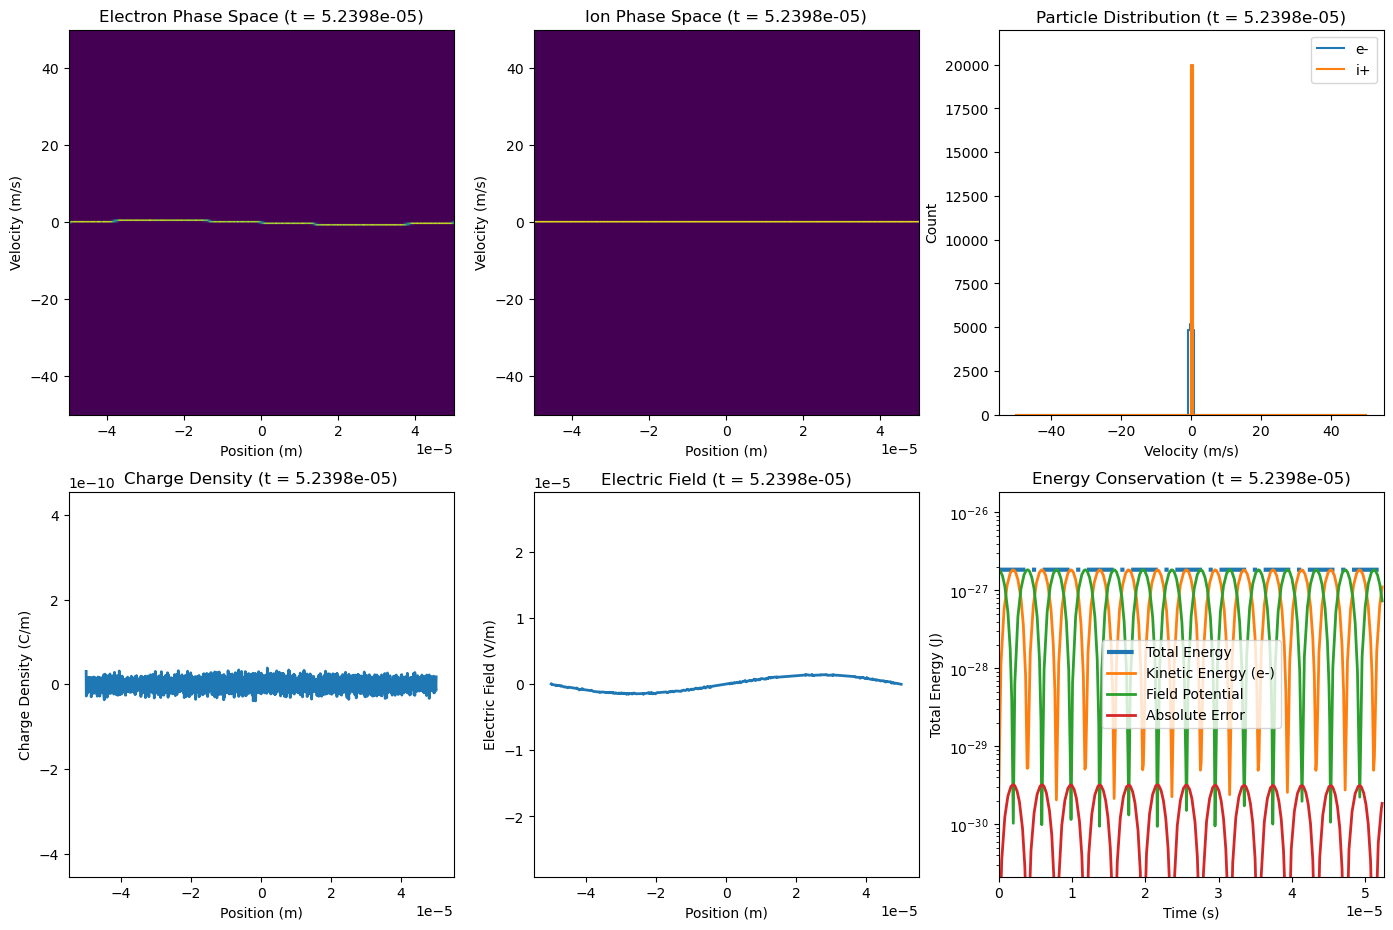

In [15]:
sweep_params: dict = {
	"x_min":			-0.00005,
	"x_max":			 0.00005,
	"v_min":			-50,
	"v_max":			 50,
	"steps_per_pd":		 75,
	"n_frames":			 500,
	"window_res":		 250,
	"f_cells_per_lam_D": 2000,
    "max_field_res":	 5000,
    "fixed_ions":		 True,
    "two_stream":		 False,
	"rho_lim_scale":	 15,
	"E_lim_scale":		 10,
	"ec_lim_margin":	 10,
	"N_e":				 20000,
	"N_i":				 20000,
	"x_pert_amp_e":		 0.05,
	"x_pert_amp_i":		 0,
    "x_pert_mode":		 1,
	"v_th_ratio_e":		 1/5000,
    "v_th_ratio_i":		 1/5000,
    "v_dr_ratio_e":		 0,
	"v_dr_ratio_i":		 0,
    "E_solver":			 1,
    "integration":		 0
}

pic_1d(sweep_params, show_plot = True, verbose = True)

In [37]:
# Fixed box length
L = 1e-4
# Fixed velocity bound length
V_L = 100
# array of v_th ratio parameters
vth_ratio_arr = np.linspace(0.005, 0.08, 100)
# convert to thermal velocities
vth_arr = vth_ratio_arr * V_L
# define number of samples taken at each density
trials_per_val = 1
N_samples = trials_per_val * len(vth_ratio_arr)

sweep_data = {
	"v_th":			[],
	"v_th_ratios":	[],
	"frequencies":	[],
	"norm_freqs":	[],
	"decays":		[]
}

# sweeping loop
for i in range(len(vth_ratio_arr)):
	sweep_params["v_min"] = -V_L/2
	sweep_params["v_max"] = V_L/2
	sweep_params["v_th_ratio_e"] = vth_ratio_arr[i]
	sweep_params["v_th_ratio_i"] = vth_ratio_arr[i]
	freqs = []
	norm_freqs = []
	decays = []
	for j in range(trials_per_val):
		sample_idx = i * trials_per_val + j + 1
		print(f"\nSample {sample_idx}/{N_samples}")
		result = pic_1d(sweep_params, show_plot = False, verbose = False)
		freqs.append(result["w_obs"])
		norm_freqs.append(result["w_obs"]**2-result["w_p_e"]**2)
		decays.append(result["obs_decay_coeff"])
	sweep_data["v_th"].append(vth_arr[i])
	sweep_data["v_th_ratios"].append(vth_ratio_arr[i])
	sweep_data["frequencies"].append(np.mean(freqs))
	sweep_data["norm_freqs"].append(np.sqrt(np.mean(norm_freqs)))
	sweep_data["decays"].append(np.mean(decays))


Sample 1/100
Current frame: 500 / 500                     
Sample 2/100
Current frame: 500 / 500                     
Sample 3/100
Current frame: 500 / 500                     
Sample 4/100
Current frame: 500 / 500                     
Sample 5/100
Current frame: 500 / 500                     
Sample 6/100
Current frame: 500 / 500                     
Sample 7/100
Current frame: 500 / 500                     
Sample 8/100
Current frame: 500 / 500                     
Sample 9/100
Current frame: 500 / 500                     
Sample 10/100
Current frame: 500 / 500                     
Sample 11/100
Current frame: 500 / 500                     
Sample 12/100
Current frame: 500 / 500                     
Sample 13/100
Current frame: 500 / 500                     
Sample 14/100
Current frame: 500 / 500                     
Sample 15/100
Current frame: 500 / 500                     
Sample 16/100
Current frame: 500 / 500                     
Sample 17/100
Current frame: 500 / 500          

C:\Users\Dugan\AppData\Local\Temp\ipykernel_17156\537009135.py:40: RuntimeWarning: invalid value encountered in sqrt
  sweep_data["norm_freqs"].append(np.sqrt(np.mean(norm_freqs)))


Current frame: 500 / 500                     
Sample 45/100
Current frame: 500 / 500                     
Sample 46/100
Current frame: 500 / 500                     
Sample 47/100
Current frame: 500 / 500                     
Sample 48/100
Current frame: 500 / 500                     
Sample 49/100
Current frame: 500 / 500                     
Sample 50/100
Current frame: 500 / 500                     
Sample 51/100
Current frame: 500 / 500                     
Sample 52/100
Current frame: 500 / 500                     
Sample 53/100
Current frame: 500 / 500                     
Sample 54/100
Current frame: 500 / 500                     
Sample 55/100
Current frame: 500 / 500                     
Sample 56/100
Current frame: 500 / 500                     
Sample 57/100
Current frame: 500 / 500                     
Sample 58/100
Current frame: 500 / 500                     
Sample 59/100
Current frame: 500 / 500                     
Sample 60/100
Current frame: 500 / 500                

A value: 82380.97906204368 ± 1532.303574316696


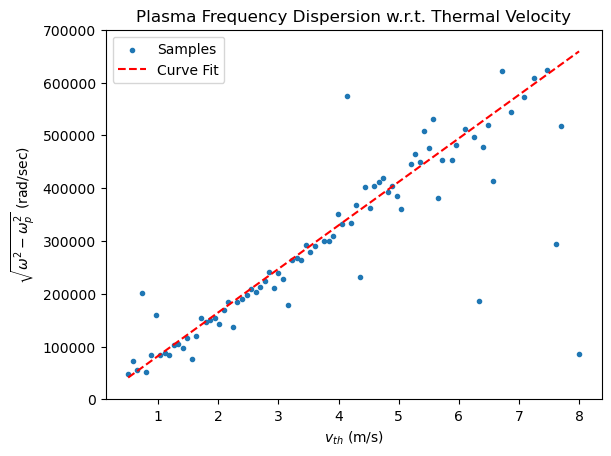

In [72]:
# k=0
def lin_fit(x, A):
	return A * x

v_data = np.array(sweep_data["v_th"])
w_data = np.array(sweep_data["norm_freqs"])

mask = ~(np.isnan(v_data) | np.isnan(w_data))

plt.scatter(v_data, w_data, marker=".", label = "Samples")
plt.title("Plasma Frequency Dispersion w.r.t. Thermal Velocity")
plt.xlabel("$v_{th}$ (m/s)")
plt.ylabel("$\sqrt{\omega^2-\omega_p^2}$ (rad/sec)")
plt.ylim(0, np.max(np.power(sweep_data["v_th"],2)))
plt.ylim(0, 700000)
popt, pcov = curve_fit(lin_fit, v_data[mask][:70], w_data[mask][:70], p0 = [1], maxfev = 10000)
n0_space = np.linspace(min(v_data), max(v_data), 500)
plt.plot(n0_space, lin_fit(n0_space, popt[0]), "--r", label = "Curve Fit")
plt.legend()

A = popt[0]
#A_real = np.sqrt(e**2 / (m_e * e_0))
sigma_A = np.sqrt(np.diag(pcov)[0])
print(f"A value: {A} ± {sigma_A}")
#print(f"Real Value: {A_real}")
#print(100 * ((A/A_real)-1))
plt.savefig(r"outputs\sweeps\v_th_sweep_omega.png")

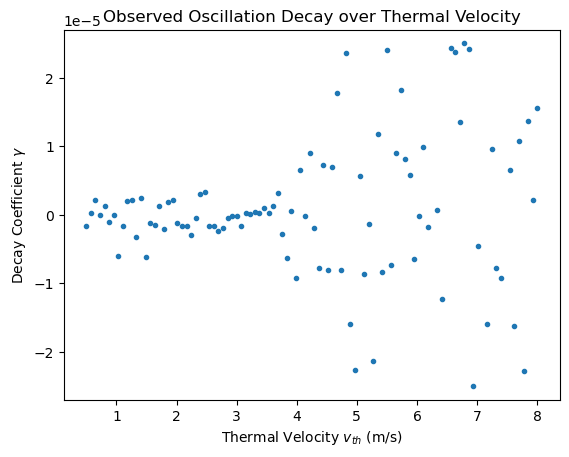

In [75]:
def gamma_func(v):
	L = sweep_params["x_max"]-sweep_params["x_min"]
	N = sweep_params["N_e"]
	n_0 = N/L
	w_p = np.sqrt((n_0 * e**2)/(m_e * e_0))
	n_m = sweep_params["x_pert_mode"]
	k = 2 * np.pi * n_m / L
	return np.sqrt(np.pi) * w_p * np.exp(-3/2) * (w_p / (k * v))**3 * np.exp(-(w_p / (k * v))**2)

plt.scatter(sweep_data["v_th"], sweep_data["decays"], marker=".", label = "Samples")
plt.title("Observed Oscillation Decay over Thermal Velocity")
plt.xlabel("Thermal Velocity $v_{th}$ (m/s)")
plt.ylabel("Decay Coefficient $\gamma$")
plt.ylim(0, np.max(sweep_data["v_th"]))
plt.ylim(-0.000027, 0.000027)
#popt, pcov = curve_fit(sqrt_fit, sweep_data["densities"], sweep_data["frequencies"], p0 = [1], maxfev = 10000)
#n0_space = np.linspace(min(sweep_data["v_th"]), max(sweep_data["v_th"]), 500)
#plt.plot(n0_space, gamma_func(n0_space), "--r", label = "Relation")
#plt.legend()

#A = popt[0]
#A_real = np.sqrt(e**2 / (m_e * e_0))
#sigma_A = np.diag(pcov)[0]
#print(f"A value: {A} ± {sigma_A}")
#print(f"Real Value: {A_real}")
#print(100 * ((A/A_real)-1))
plt.savefig(r"outputs\sweeps\v_th_sweep_gamma.png")